In [ ]:
import requests
import folium
import pandas as pd
import matplotlib.pyplot as plt
import time

# --------------------------------------------------
# 1. Punto solicitado al endpoint
# --------------------------------------------------
pour_lat = -15.2550
pour_lon = -69.8730

url = "https://fluviotech.com/api/watersheds/delineate/"

payload = {
    "lat": pour_lat,
    "lon": pour_lon
}

response = requests.post(url, json=payload)
response.raise_for_status()

data = response.json()

# --------------------------------------------------
# 2. Separar capas devueltas por la API
# --------------------------------------------------
catchment_geojson = data["catchment"]
river_network_geojson = data["river_network"]

In [24]:
URL_DAILY = "https://fluviotech.com/meteodata/pisco/daily/series/"
URL_TEMP = "https://fluviotech.com/meteodata/api/pisco/temperature/daily/"
URL_CAUDALES = "https://fluviotech.com/hydrostations/api/series/"

In [13]:
def consultar_api_pisco(url, payload):
    """Envía una consulta POST a la API de PISCO y devuelve el JSON de respuesta.

    Parámetros
    ----------
    url : str
        Endpoint de la API.
    payload : dict
        Cuerpo de la consulta. Debe incluir fechas, geometría y opcionalmente aggregation.

    Retorna
    -------
    dict
        Respuesta de la API en formato JSON.
    """
    response = requests.post(url, json=payload)

    print("Código de estado:", response.status_code)
    print("Vista previa de respuesta:", response.text[:300])

    response.raise_for_status()
    return response.json()

def consultar_temperatura(payload):
    """Consulta la API de temperatura diaria y devuelve un DataFrame."""
    response = requests.post(URL_TEMP, json=payload)

    print("Código de estado:", response.status_code)
    print("Vista previa:", response.text[:300])

    response.raise_for_status()
    result = response.json()

    df = pd.DataFrame(result["data"])
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])

    return result, df

In [60]:
geometry_cuenca = catchment_geojson["features"][0]["geometry"]

payload_poligono_mean = {
    "start": "1981-01-01",
    "end": "2020-12-31",
    "aggregation": "mean",
    "geometry": geometry_cuenca
}

result = consultar_api_pisco(URL_DAILY, payload_poligono_mean)

df_poly_mean = pd.DataFrame(result["data"])
df_poly_mean["date"] = pd.to_datetime(df_poly_mean["date"])

Código de estado: 200
Vista previa de respuesta: {"dataset":"PISCO precipitation v3 (daily)","start":"1981-01-01","end":"2020-12-31","geometry_type":"Polygon","aggregation":"mean","pixels_count":123,"data":[{"date":"1981-01-01","precipitation_mean":3.757},{"date":"1981-01-02","precipitation_mean":4.311},{"date":"1981-01-03","precipitation_mean":6.


In [22]:
import pandas as pd
import time

# 1. Crear una lista de rangos de años
años = range(1981, 2021)  # De 1981 a 2010
dataframes_anuales = []
resultados_raw = []

print("Iniciando descarga por partes para evitar el Timeout 524...")

for año in años:
    print(f"Consultando año: {año}...")
    
    # Modificamos las fechas dinámicamente para cada año
    payload_anual = {
        "geometry": geometry_cuenca,
        "start": f"{año}-01-01",
        "end": f"{año}-12-31",
        "variables": ["tmin", "tmax"],
        "aggregation": "mean"
    }
    
    try:
        # Hacemos la consulta para un solo año
        result, df_temp = consultar_temperatura(payload_anual)
        
        # Guardamos los resultados
        dataframes_anuales.append(df_temp)
        resultados_raw.append(result)
        
        # Una pequeña pausa para no saturar el servidor de peticiones consecutivas
        time.sleep(1) 
        
    except Exception as e:
        print(f"Error al consultar el año {año}: {e}")
        # Aquí puedes decidir si romper el ciclo o continuar

# 2. Consolidar todos los DataFrames en uno solo
if dataframes_anuales:
    df_temp_mean = pd.concat(dataframes_anuales, ignore_index=True)
    print("\n¡Descarga completada con éxito!")
    print("Columnas:", df_temp_mean.columns.tolist())
    print(df_temp_mean.head())
else:
    print("No se pudo obtener ninguna información.")

Iniciando descarga por partes para evitar el Timeout 524...
Consultando año: 1981...
Código de estado: 200
Vista previa: {"datasets":{"tmin":"PISCO tmin v1 (daily)","tmax":"PISCO tmax v1 (daily)"},"start":"1981-01-01","end":"1981-12-31","geometry_type":"Polygon","aggregation":"mean","pixels_count":495,"variables":["tmin","tmax"],"data":[{"date":"1981-01-01","tmin_mean":1.851,"tmax_mean":15.455},{"date":"1981-01-02","t
Consultando año: 1982...
Código de estado: 200
Vista previa: {"datasets":{"tmin":"PISCO tmin v1 (daily)","tmax":"PISCO tmax v1 (daily)"},"start":"1982-01-01","end":"1982-12-31","geometry_type":"Polygon","aggregation":"mean","pixels_count":495,"variables":["tmin","tmax"],"data":[{"date":"1982-01-01","tmin_mean":3.009,"tmax_mean":12.63},{"date":"1982-01-02","tm
Consultando año: 1983...
Código de estado: 200
Vista previa: {"datasets":{"tmin":"PISCO tmin v1 (daily)","tmax":"PISCO tmax v1 (daily)"},"start":"1983-01-01","end":"1983-12-31","geometry_type":"Polygon","aggregation"

In [28]:
params = {
    "gauge_id": "PE_47251282",
    "start": "1981-01-01",
    "end": "2020-12-31"
}

response = requests.get(URL_CAUDALES, params=params)

result = response.json()

df = pd.DataFrame(result["data"])
df["date"] = pd.to_datetime(df["date"])

# Ordenamos por fecha por seguridad
df = df.sort_values("date").reset_index(drop=True)

print(df.shape)
df.head()

(14610, 3)


,date,flow_obs,flow_sim
0,1981-01-01,NaN,1.000
1,1981-01-02,NaN,1.107
2,1981-01-03,NaN,1.196
3,1981-01-04,NaN,1.217
4,1981-01-05,NaN,1.188


In [35]:
df_temp_mean["date"] = pd.to_datetime(df_temp_mean["date"])

In [61]:
df_final = (
    df
    .merge(df_poly_mean, on='date', how='left')
    .merge(df_temp_mean, on='date', how='left')
)

In [62]:
df_final.to_csv("ramis_hydro.csv",index=False)

In [63]:
df_final.describe()

,date,flow_obs,flow_sim,precipitation_mean,tmin_mean,tmax_mean
count,14610,10529.000000,14610.000000,14610.000000,14610.000000,14610.000000
mean,2000-12-31 12:00:00,0.421849,0.449596,1.934491,-1.554561,14.526043
min,1981-01-01 00:00:00,0.020000,0.014000,0.000000,-12.660000,7.997000
25%,1991-01-01 06:00:00,0.071000,0.071000,0.064000,-4.696500,13.432500
50%,2000-12-31 12:00:00,0.142000,0.149000,0.691000,-0.635500,14.526000
75%,2010-12-31 18:00:00,0.575000,0.598000,2.931750,1.724000,15.636000
max,2020-12-31 00:00:00,3.244000,3.244000,19.337000,4.760000,20.327000
std,NaN,0.549889,0.593859,2.653740,3.768561,1.644422


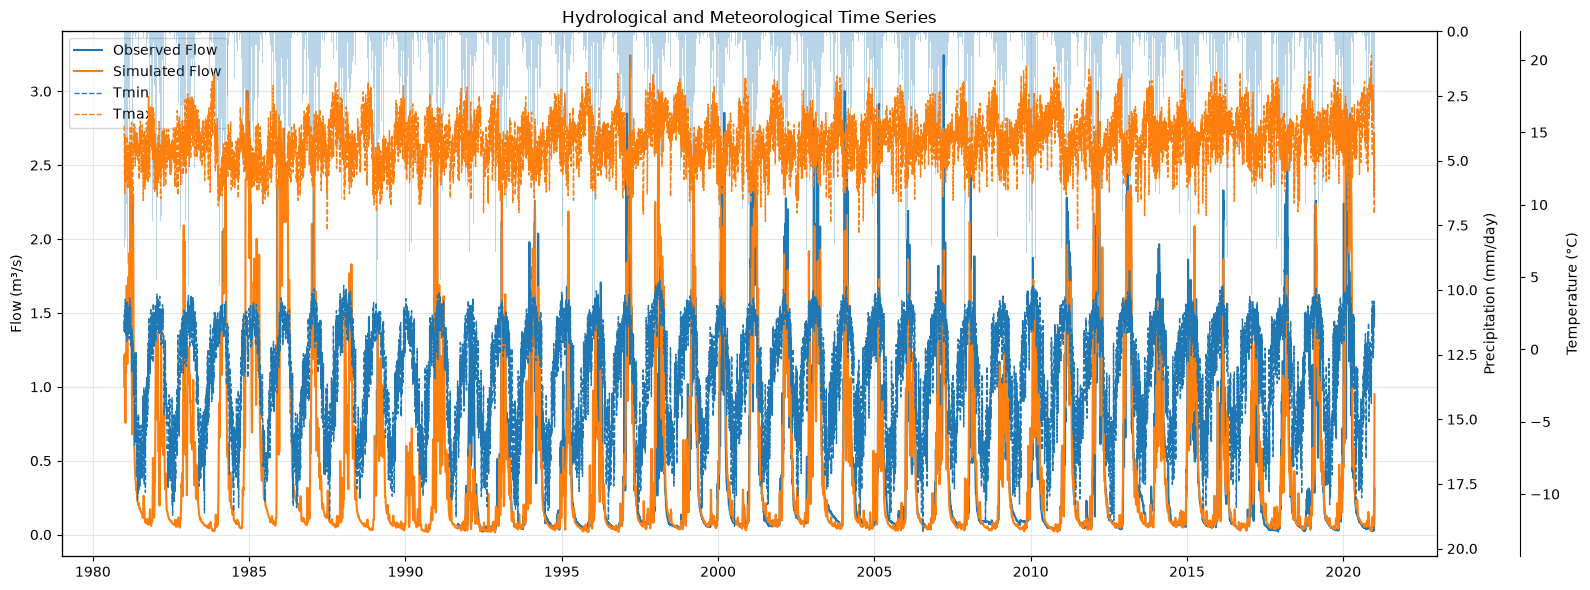

In [64]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(16, 6))

# Caudales
ax1.plot(df_final['date'], df_final['flow_obs'],
         lw=1.5, label='Observed Flow')
ax1.plot(df_final['date'], df_final['flow_sim'],
         lw=1.5, label='Simulated Flow')

ax1.set_ylabel('Flow (m³/s)')
ax1.grid(alpha=0.3)

# Precipitación
ax2 = ax1.twinx()

ax2.bar(
    df_final['date'],
    df_final['precipitation_mean'],
    width=1,
    alpha=0.3,
    label='Precipitation'
)

ax2.invert_yaxis()
ax2.set_ylabel('Precipitation (mm/day)')

# Temperaturas
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))

ax3.plot(
    df_final['date'],
    df_final['tmin_mean'],
    '--',
    lw=1,
    label='Tmin'
)

ax3.plot(
    df_final['date'],
    df_final['tmax_mean'],
    '--',
    lw=1,
    label='Tmax'
)

ax3.set_ylabel('Temperature (°C)')

# Leyenda combinada
lines = ax1.get_lines() + ax3.get_lines()
labels = [l.get_label() for l in lines]

ax1.legend(lines, labels, loc='upper left')

plt.title('Hydrological and Meteorological Time Series')
plt.tight_layout()
plt.show()